In [94]:
# ============================================================================
# IMPORTS - BIBLIOTHÈQUES DE MODÉLISATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Machine Learning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Modèles
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
try:
    from lightgbm import LGBMRegressor
except ImportError:
    print("⚠️ LightGBM non installé")

try:
    from catboost import CatBoostRegressor
except ImportError:
    print("⚠️ CatBoost non installé")

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    print("⚠️ TensorFlow non installé")

# Configuration
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliothèques chargées avec succès!")
print(f"📊 Pandas: {pd.__version__}")
print(f"🔢 NumPy: {np.__version__}")

✅ Bibliothèques chargées avec succès!
📊 Pandas: 2.2.3
🔢 NumPy: 2.1.3


In [95]:
# ============================================================================
# CHARGEMENT DES DONNÉES
# ============================================================================

print("📂 Chargement du dataset préparé...")

df = pd.read_csv('3.dataset_feature_engineered/df_model_final_with_advanced_time_features.csv', sep=';')

print(f"✅ Dataset chargé: {df.shape}")
print(f"\n📋 Colonnes disponibles:")
for col in df.columns:
    print(f"  • {col}")

# Convertir la colonne date en datetime
df['date_heure_comptage'] = pd.to_datetime(df['date_heure_comptage'])

# Afficher infos
print(f"\n📊 Informations du dataset:")
print(f"  • Période: {df['date_heure_comptage'].min()} → {df['date_heure_comptage'].max()}")
print(f"  • Nombre d'observations: {len(df)}")
print(f"\n📈 Statistiques des variables cibles:")
print(df[['debit_horaire', 'taux_occupation']].describe())

📂 Chargement du dataset préparé...
✅ Dataset chargé: (9266, 47)

📋 Colonnes disponibles:
  • date_heure_comptage
  • debit_horaire
  • taux_occupation
  • etat_trafic
  • etat_arc
  • est_vacances
  • est_ferie
  • precipitation
  • duree_precipitation_min
  • vitesse_vent_ms
  • date_only
  • heure
  • jour_semaine
  • jour_mois
  • mois
  • annee
  • semaine_annee
  • est_weekend
  • heure_sin
  • heure_cos
  • jour_semaine_sin
  • jour_semaine_cos
  • mois_sin
  • mois_cos
  • est_pietonnise
  • veille_weekend
  • veille_ferie
  • veille_vacances
  • lendemain_weekend
  • lendemain_ferie
  • rentree_vacances
  • est_pont
  • semaine_cheval_mois
  • heure_pointe_matin
  • heure_pointe_soir
  • heure_creuse
  • heure_midi
  • nuit_profonde
  • mauvais_temps
  • tres_mauvais_temps
  • periode_noel
  • rentree_septembre
  • periode_ete
  • weekend_beau_temps
  • vacances_pietonnise
  • ferie_mauvais_temps
  • pointe_mauvais_temps

📊 Informations du dataset:
  • Période: 2024-09-01 05:00

In [96]:
# ============================================================================
# SÉLECTION DES FEATURES PERTINENTES
# ============================================================================

print("🔍 Sélection des features pour la modélisation...")

# -------------------------
# VARIABLES À EXCLURE (data leakage ou inutiles)
# -------------------------
colonnes_a_exclure = [
    'date_heure_comptage',  # Identifiant temporel (on garde que les features extraites)
    'date_only',            # Redondant
    'etat_trafic',          # DATA LEAKAGE - corrélé avec les cibles
    'etat_arc',             # Métadonnée technique non pertinente
]

print("\n❌ Colonnes exclues (data leakage ou inutiles):")
for col in colonnes_a_exclure:
    if col in df.columns:
        print(f"  • {col}")

# -------------------------
# VARIABLES CIBLES
# -------------------------
target_columns = ['debit_horaire', 'taux_occupation']

print("\n🎯 Variables cibles:")
for col in target_columns:
    print(f"  • {col}")

# -------------------------
# FEATURES POUR L'ENTRAÎNEMENT
# -------------------------
# Toutes les colonnes sauf cibles et colonnes à exclure
feature_columns = [col for col in df.columns 
                   if col not in target_columns 
                   and col not in colonnes_a_exclure]

print(f"\n✅ Features sélectionnées ({len(feature_columns)}):")
print("\n📅 Temporelles:")
features_temporelles = [col for col in feature_columns if any(x in col for x in ['heure', 'jour', 'mois', 'annee', 'semaine', 'weekend'])]
for col in features_temporelles:
    print(f"  • {col}")

print("\n🌍 Externes:")
features_externes = [col for col in feature_columns if any(x in col for x in ['vacances', 'ferie', 'precipitation', 'vent'])]
for col in features_externes:
    print(f"  • {col}")

# -------------------------
# NETTOYAGE DES DONNÉES
# -------------------------
print("\n🧹 Nettoyage des données...")

# Supprimer les lignes avec valeurs manquantes dans les cibles
nb_avant = len(df)
df_clean = df.dropna(subset=target_columns).copy()
nb_apres = len(df_clean)

if nb_avant > nb_apres:
    print(f"  • {nb_avant - nb_apres} lignes supprimées (valeurs manquantes dans les cibles)")

# Remplir les valeurs manquantes dans les features (météo principalement)
for col in feature_columns:
    if df_clean[col].isna().sum() > 0:
        # Pour les features numériques, remplacer par la médiane
        if df_clean[col].dtype in ['float64', 'int64']:
            mediane = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(mediane)
            print(f"  • {col}: {df_clean[col].isna().sum()} NaN remplacés par médiane ({mediane:.2f})")

print(f"\n✅ Dataset nettoyé: {df_clean.shape}")
print(f"📊 Valeurs manquantes restantes: {df_clean[feature_columns].isna().sum().sum()}")

🔍 Sélection des features pour la modélisation...

❌ Colonnes exclues (data leakage ou inutiles):
  • date_heure_comptage
  • date_only
  • etat_trafic
  • etat_arc

🎯 Variables cibles:
  • debit_horaire
  • taux_occupation

✅ Features sélectionnées (41):

📅 Temporelles:
  • heure
  • jour_semaine
  • jour_mois
  • mois
  • annee
  • semaine_annee
  • est_weekend
  • heure_sin
  • heure_cos
  • jour_semaine_sin
  • jour_semaine_cos
  • mois_sin
  • mois_cos
  • veille_weekend
  • lendemain_weekend
  • semaine_cheval_mois
  • heure_pointe_matin
  • heure_pointe_soir
  • heure_creuse
  • heure_midi
  • weekend_beau_temps

🌍 Externes:
  • est_vacances
  • est_ferie
  • precipitation
  • duree_precipitation_min
  • vitesse_vent_ms
  • veille_ferie
  • veille_vacances
  • lendemain_ferie
  • rentree_vacances
  • vacances_pietonnise
  • ferie_mauvais_temps

🧹 Nettoyage des données...
  • 622 lignes supprimées (valeurs manquantes dans les cibles)
  • duree_precipitation_min: 0 NaN remplacés pa

In [97]:
df.drop(columns=[    'etat_trafic',          # DATA LEAKAGE - corrélé avec les cibles
    'etat_arc',], inplace=True)

In [98]:
df = df.dropna(subset=['debit_horaire']).reset_index(drop=True)

In [47]:
cols = df.columns.tolist()
print(cols)

['date_heure_comptage', 'debit_horaire', 'taux_occupation', 'est_vacances', 'est_ferie', 'precipitation', 'duree_precipitation_min', 'vitesse_vent_ms', 'date_only', 'heure', 'jour_semaine', 'jour_mois', 'mois', 'annee', 'semaine_annee', 'est_weekend', 'heure_sin', 'heure_cos', 'jour_semaine_sin', 'jour_semaine_cos', 'mois_sin', 'mois_cos', 'est_pietonnise', 'veille_weekend', 'veille_ferie', 'veille_vacances', 'lendemain_weekend', 'lendemain_ferie', 'rentree_vacances', 'est_pont', 'semaine_cheval_mois', 'heure_pointe_matin', 'heure_pointe_soir', 'heure_creuse', 'heure_midi', 'nuit_profonde', 'mauvais_temps', 'tres_mauvais_temps', 'periode_noel', 'rentree_septembre', 'periode_ete', 'weekend_beau_temps', 'vacances_pietonnise', 'ferie_mauvais_temps', 'pointe_mauvais_temps']


In [99]:
# Toutes les moyennes pertinentes
aggregations = {
    'mean_by_hour': ['heure'],
    'mean_by_day': ['jour_semaine'],
    'mean_by_month': ['mois'],
    'mean_by_vacances': ['est_vacances'],
    'mean_by_ferie': ['est_ferie'],
    'mean_by_hour_day': ['heure', 'jour_semaine'],
    'mean_by_hour_month': ['heure', 'mois'],
    'mean_by_hour_vacances': ['heure', 'est_vacances'],
    'mean_by_hour_ferie': ['heure', 'est_ferie'],
    'mean_by_day_vacances': ['jour_semaine', 'est_vacances'],
    'mean_by_hour_day_vacances': ['heure', 'jour_semaine', 'est_vacances']
}

for feature_name, group_cols in aggregations.items():
    mean_grouped = df.groupby(group_cols)['debit_horaire'].mean()
    if len(group_cols) == 1:
        df[feature_name] = df[group_cols[0]].map(mean_grouped)
    else:
        df[feature_name] = df.apply(
            lambda row: mean_grouped.get(tuple(row[col] for col in group_cols), np.nan), 
            axis=1
        )
        # Remplir les NaN avec la moyenne globale
        df[feature_name].fillna(df['debit_horaire'].mean(), inplace=True)

print(f"Total features: {df.shape[1]}")

Total features: 56


In [100]:
df['lag'] = df['debit_horaire'].shift(72)
df = df.sort_values('date_heure_comptage').reset_index(drop=True)
df['debit_horaire'].isna().sum()


np.int64(0)

In [101]:
# Définition propre de la liste des features
cols_to_drop = {'debit_horaire', 'taux_occupation','etat_arc', 'etat_trafic', 'date_only', 'date_heure_comptage'}
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['debit_horaire']

In [80]:
X.columns

Index(['est_vacances', 'est_ferie', 'precipitation', 'duree_precipitation_min',
       'vitesse_vent_ms', 'heure', 'jour_semaine', 'jour_mois', 'mois',
       'annee', 'semaine_annee', 'est_weekend', 'heure_sin', 'heure_cos',
       'jour_semaine_sin', 'jour_semaine_cos', 'mois_sin', 'mois_cos',
       'est_pietonnise', 'veille_weekend', 'veille_ferie', 'veille_vacances',
       'lendemain_weekend', 'lendemain_ferie', 'rentree_vacances', 'est_pont',
       'semaine_cheval_mois', 'heure_pointe_matin', 'heure_pointe_soir',
       'heure_creuse', 'heure_midi', 'nuit_profonde', 'mauvais_temps',
       'tres_mauvais_temps', 'periode_noel', 'rentree_septembre',
       'periode_ete', 'weekend_beau_temps', 'vacances_pietonnise',
       'ferie_mauvais_temps', 'pointe_mauvais_temps', 'mean_by_hour',
       'mean_by_day', 'mean_by_month', 'mean_by_vacances', 'mean_by_ferie',
       'mean_by_hour_day', 'mean_by_hour_month', 'mean_by_hour_vacances',
       'mean_by_hour_ferie', 'mean_by_day_vacance

In [50]:
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [61]:
X_train = X.iloc[:-72]
X_test = X.iloc[-72:]
y_train = y.iloc[:-72]
y_test = y.iloc[-72:]

In [102]:
y_test

9178    597.0
9179    749.0
9180    776.0
9181    811.0
9182    818.0
        ...  
9254    387.0
9258    930.0
9259    286.0
9260    235.0
9261    322.0
Name: debit_horaire, Length: 72, dtype: float64

In [103]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_lambda=1.0,   # L2 regularization
    reg_alpha=0.1,    # L1 regularization
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',  # ✅ tout en minuscules !
    early_stopping_rounds=50,
)
for i in range(len(df)//2,len(df),len(df)//20):
    RMSE = []
    X_train = X.iloc[:i-72]
    y_train = y.iloc[:i-72]
    X_test = X.iloc[i-72:i]
    y_test = y.iloc[i-72:i]
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )


    y_pred_xgb = xgb.predict(X_test)

    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    RMSE.append(rmse_xgb)
    rmse_xgb_train = np.sqrt(mean_squared_error(y_train, xgb.predict(X_train)))
    r2_xgb = r2_score(y_test, y_pred_xgb)
    print(f" ✓ RMSE Train={rmse_xgb_train:.2f} RMSE={rmse_xgb:.2f}, R²={r2_xgb:.4f}")

print(sum(RMSE)/len(RMSE))

 ✓ RMSE Train=52.94 RMSE=71.39, R²=0.9505
 ✓ RMSE Train=97.90 RMSE=130.78, R²=0.7838
 ✓ RMSE Train=98.95 RMSE=87.48, R²=0.8484
 ✓ RMSE Train=108.57 RMSE=178.84, R²=0.1293
 ✓ RMSE Train=42.80 RMSE=94.87, R²=0.8879
 ✓ RMSE Train=115.27 RMSE=98.97, R²=0.8427
 ✓ RMSE Train=36.08 RMSE=75.36, R²=0.8568
 ✓ RMSE Train=280.59 RMSE=270.63, R²=-0.0261
 ✓ RMSE Train=140.67 RMSE=197.24, R²=0.4482
 ✓ RMSE Train=151.98 RMSE=139.58, R²=0.6080
 ✓ RMSE Train=98.69 RMSE=75.78, R²=0.9239
75.77880495288522


In [104]:
len(df)

8703

In [105]:
y_test.index

RangeIndex(start=8629, stop=8701, step=1)

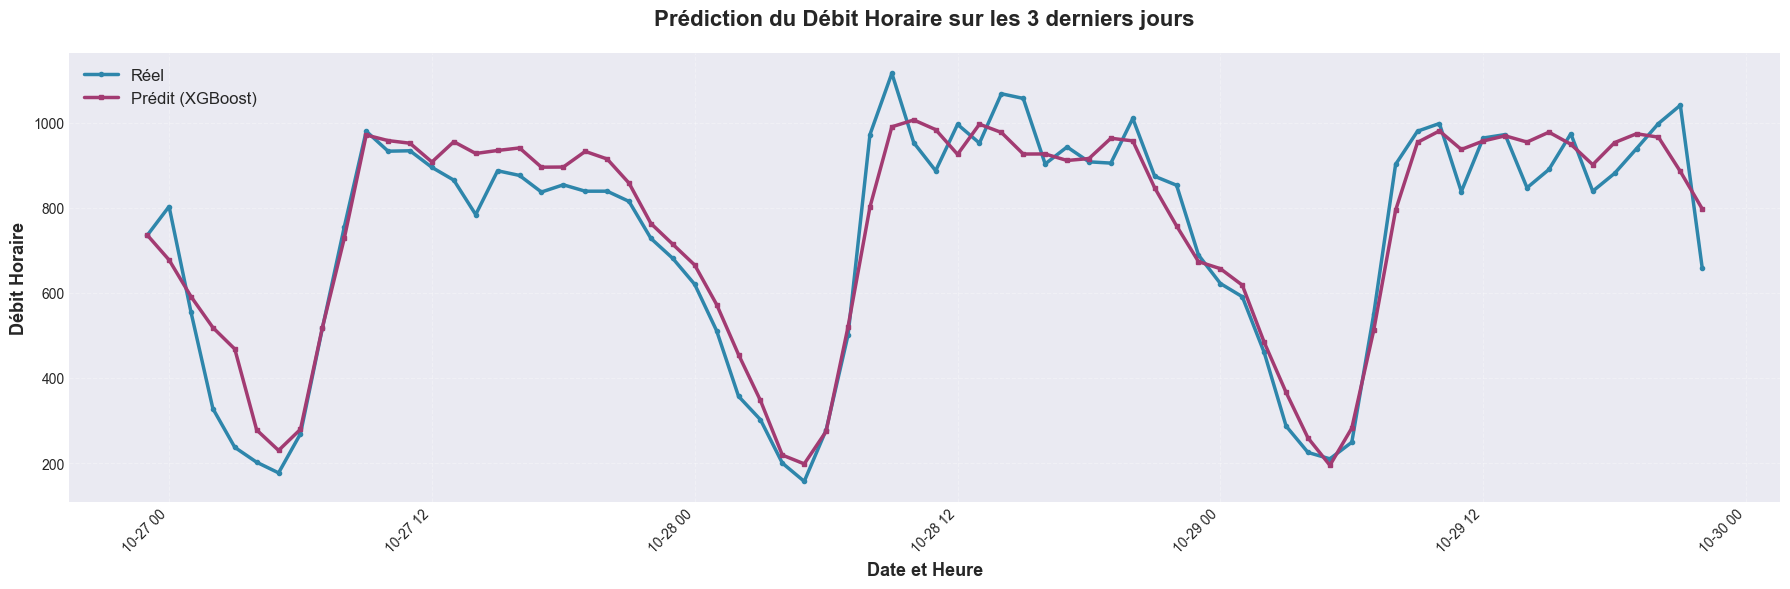

In [106]:
import matplotlib.pyplot as plt

# Récupérer les dates du test set
dates_test = df.loc[X_test.index, 'date_heure_comptage']

# Créer le graphique
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(dates_test, y_test.values, label='Réel', linewidth=2.5, color='#2E86AB', marker='o', markersize=3)
ax.plot(dates_test, y_pred_xgb, label='Prédit (XGBoost)', linewidth=2.5, color='#A23B72', marker='s', markersize=3)

ax.set_title('Prédiction du Débit Horaire sur les 3 derniers jours', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date et Heure', fontsize=13, fontweight='bold')
ax.set_ylabel('Débit Horaire', fontsize=13, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')

# Rotation et alignement des dates
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [64]:
from xgboost import XGBRegressor, callback
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def refined_search_xgb(X_train, y_train, X_test, y_test, best_params_list, n_iter_per_best=1000, random_state=42):
    """
    best_params_list: liste de dict avec les meilleures combinaisons à affiner
    n_iter_per_best: nombre d'itérations autour de chaque meilleur
    """
    np.random.seed(random_state)
    results = []

    for best_idx, best_params in enumerate(best_params_list):
        for i in range(n_iter_per_best):
            # Générer des hyperparamètres autour du best
            params = {
                'n_estimators': int(np.clip(np.random.normal(best_params['n_estimators'], 100), 300, 1200)),
                'learning_rate': float(np.clip(np.random.normal(best_params['learning_rate'], 0.05), 0.01, 0.3)),
                'max_depth': int(np.clip(np.random.randint(best_params['max_depth']-1, best_params['max_depth']+2), 3, 10)),
                'subsample': float(np.clip(np.random.normal(best_params['subsample'], 0.05), 0.5, 1.0)),
                'colsample_bytree': float(np.clip(np.random.normal(best_params['colsample_bytree'], 0.05), 0.5, 1.0)),
                'reg_lambda': float(np.clip(np.random.normal(best_params.get('reg_lambda',1.0), 0.5), 0.0, 5.0)),
                'reg_alpha': float(np.clip(np.random.normal(best_params.get('reg_alpha',0.1), 0.5), 0.0, 5.0)),
            }
            early_stop = callback.EarlyStopping(
                rounds=30,
                save_best=True,
                maximize=False
            )
            model = XGBRegressor(
                **params,
                random_state=random_state,
                n_jobs=-1,
                eval_metric='rmse',
                callbacks=[early_stop]

            )



            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False,
            )

            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

            rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
            rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
            mae = mean_absolute_error(y_test, y_pred_test)
            r2 = r2_score(y_test, y_pred_test)

            results.append({
                'best_idx': best_idx,
                'iteration': i+1,
                **params,
                'rmse_train': rmse_train,
                'rmse_test': rmse_test,
                'mae': mae,
                'r2': r2
            })

        print(f"Refinement done for best_params index {best_idx}")

    df_results = pd.DataFrame(results)
    return df_results.sort_values(by='rmse_test').reset_index(drop=True)

# Exemple d’usage avec tes deux meilleurs
best_params_list = [
    {'n_estimators': 791, 'learning_rate': 0.188325, 'max_depth': 4, 'subsample': 0.672730, 'colsample_bytree':0.673362, 'reg_lambda':0.678060, 'reg_alpha':0.524756},
    {'n_estimators': 530, 'learning_rate': 0.182297, 'max_depth': 3, 'subsample': 0.691174, 'colsample_bytree':0.770843, 'reg_lambda':1.654228, 'reg_alpha':0.860731},
    {'n_estimators': 420, 'learning_rate': 0.218946, 'max_depth': 3, 'subsample': 0.752557, 'colsample_bytree':0.710361, 'reg_lambda':2.490514, 'reg_alpha':1.070241}
]

df_refined = refined_search_xgb(X_train, y_train, X_test, y_test, best_params_list, n_iter_per_best=100)
print(df_refined.head())


Refinement done for best_params index 0
Refinement done for best_params index 1
Refinement done for best_params index 2
   best_idx  iteration  n_estimators  learning_rate  max_depth  subsample  \
0         1         39           634       0.177559          3   0.672658   
1         0          5           832       0.229948          3   0.642698   
2         0          2           589       0.163685          5   0.649256   
3         1         61           639       0.176760          4   0.747737   
4         2         59           401       0.268232          4   0.772051   

   colsample_bytree  reg_lambda  reg_alpha  rmse_train  rmse_test        mae  \
0          0.729165    1.309458   1.108209  101.299284  78.816006  58.235521   
1          0.658777    0.377207   1.450895   91.403819  79.001224  57.760665   
2          0.700490    0.446351   0.291891   58.589885  79.719263  58.156343   
3          0.757106    2.346449   1.239459   76.502887  80.722834  60.563510   
4          0.6717

In [66]:
from xgboost import XGBRegressor, callback
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd

def refined_search_xgb_cv_ts(X, y, best_params_list, n_iter_per_best=1000, n_splits=5, random_state=42):
    """
    Refined hyperparameter search using TimeSeriesSplit cross-validation
    for time series prediction.

    Parameters:
        X, y: full dataset (chronologically ordered)
        best_params_list: list of dicts with best previous hyperparameter sets
        n_iter_per_best: number of iterations per best hyperparameter set
        n_splits: number of CV folds
        random_state: seed for reproducibility

    Returns:
        df_results: DataFrame with results sorted by mean CV RMSE
    """
    np.random.seed(random_state)
    results = []
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for best_idx, best_params in enumerate(best_params_list):
        for i in range(n_iter_per_best):
            # Generate hyperparameters around the best
            params = {
                'n_estimators': int(np.clip(np.random.normal(best_params['n_estimators'], 100), 300, 1200)),
                'learning_rate': float(np.clip(np.random.normal(best_params['learning_rate'], 0.05), 0.01, 0.3)),
                'max_depth': int(np.clip(np.random.randint(best_params['max_depth']-1, best_params['max_depth']+2), 3, 10)),
                'subsample': float(np.clip(np.random.normal(best_params['subsample'], 0.05), 0.5, 1.0)),
                'colsample_bytree': float(np.clip(np.random.normal(best_params['colsample_bytree'], 0.05), 0.5, 1.0)),
                'reg_lambda': float(np.clip(np.random.normal(best_params.get('reg_lambda',1.0), 0.5), 0.0, 5.0)),
                'reg_alpha': float(np.clip(np.random.normal(best_params.get('reg_alpha',0.1), 0.5), 0.0, 5.0)),
            }

            rmse_train_folds = []
            rmse_test_folds = []
            mae_folds = []
            r2_folds = []

            for train_idx, val_idx in tscv.split(X):
                X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
                y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

                early_stop = callback.EarlyStopping(
                    rounds=30,
                    save_best=True,
                    maximize=False
                )
                model = XGBRegressor(
                    **params,
                    random_state=random_state,
                    n_jobs=-1,
                    eval_metric='rmse',
                    callbacks=[early_stop]
                )

                model.fit(
                    X_train_cv, y_train_cv,
                    eval_set=[(X_val_cv, y_val_cv)],
                    verbose=False
                )

                y_pred_train = model.predict(X_train_cv)
                y_pred_val = model.predict(X_val_cv)

                rmse_train_folds.append(np.sqrt(mean_squared_error(y_train_cv, y_pred_train)))
                rmse_test_folds.append(np.sqrt(mean_squared_error(y_val_cv, y_pred_val)))
                mae_folds.append(mean_absolute_error(y_val_cv, y_pred_val))
                r2_folds.append(r2_score(y_val_cv, y_pred_val))

            results.append({
                'best_idx': best_idx,
                'iteration': i+1,
                **params,
                'rmse_train': np.mean(rmse_train_folds),
                'rmse_test': np.mean(rmse_test_folds),
                'mae': np.mean(mae_folds),
                'r2': np.mean(r2_folds)
            })

        print(f"Refinement done for best_params index {best_idx}")

    df_results = pd.DataFrame(results)
    return df_results.sort_values(by='rmse_test').reset_index(drop=True)


# Exemple d'utilisation
best_params_list = [
    {'n_estimators': 791, 'learning_rate': 0.188325, 'max_depth': 4, 'subsample': 0.672730, 'colsample_bytree':0.673362, 'reg_lambda':0.678060, 'reg_alpha':0.524756},
    {'n_estimators': 530, 'learning_rate': 0.182297, 'max_depth': 3, 'subsample': 0.691174, 'colsample_bytree':0.770843, 'reg_lambda':1.654228, 'reg_alpha':0.860731},
    {'n_estimators': 420, 'learning_rate': 0.218946, 'max_depth': 3, 'subsample': 0.752557, 'colsample_bytree':0.710361, 'reg_lambda':2.490514, 'reg_alpha':1.070241}
]

# Utiliser le dataset complet chronologique
df_refined = refined_search_xgb_cv_ts(X, y,
                                      best_params_list, n_iter_per_best=10)
print(df_refined.head())


Refinement done for best_params index 0
Refinement done for best_params index 1
Refinement done for best_params index 2
   best_idx  iteration  n_estimators  learning_rate  max_depth  subsample  \
0         0          2           589       0.163685          5   0.649256   
1         1          7           490       0.167840          4   0.667018   
2         2          9           550       0.151770          4   0.682237   
3         0          1           840       0.181412          5   0.696423   
4         2          3           381       0.174670          3   0.762840   

   colsample_bytree  reg_lambda  reg_alpha  rmse_train   rmse_test        mae  \
0          0.700490    0.446351   0.291891   80.780881  139.730214  91.804227   
1          0.742352    0.608428   1.492601   93.620718  140.002261  93.085549   
2          0.708635    2.009006   1.558831   96.184956  140.523945  93.152355   
3          0.741785    0.219647   0.462682   83.852667  140.853864  93.465265   
4          0

📊 Génération de la courbe Prédictions vs Réalité...


NameError: name 'y_pred_ensemble' is not defined

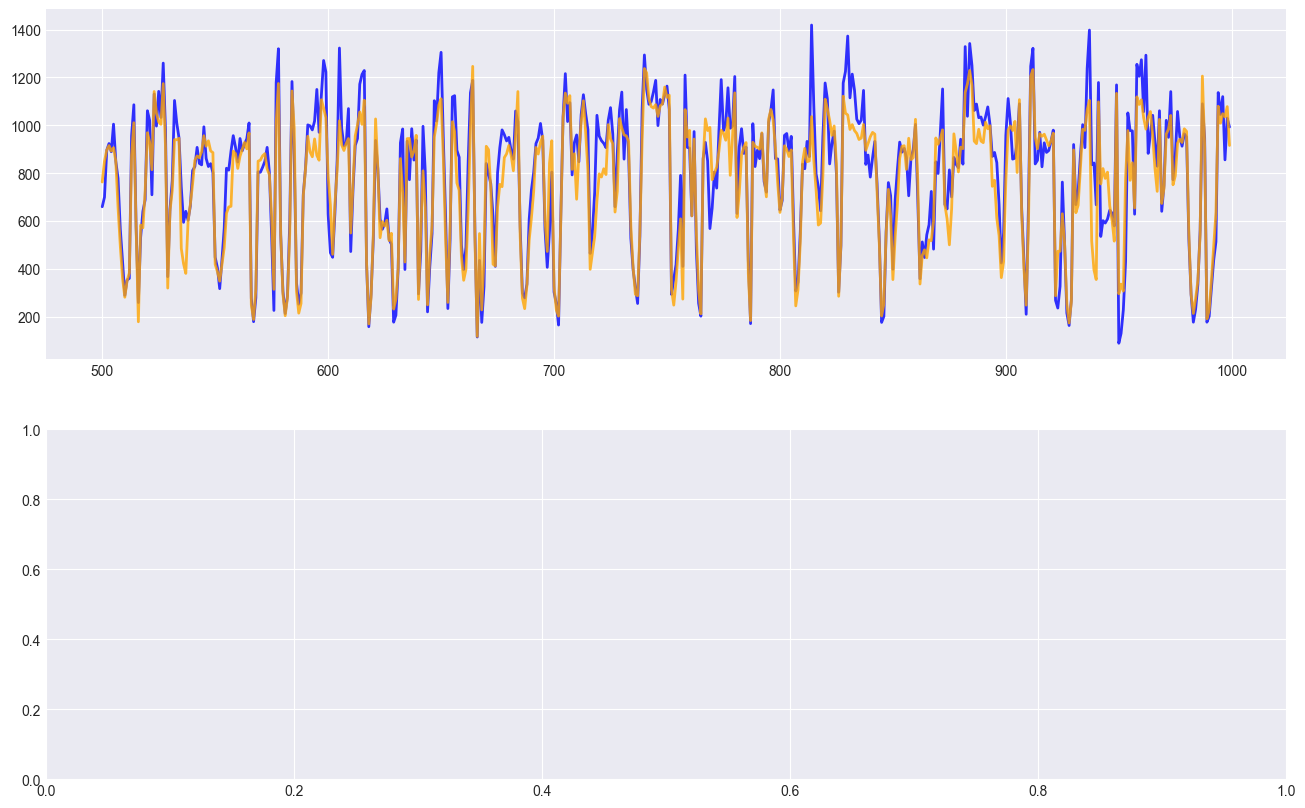

In [54]:
# ============================================================================
# 📊 VISUALISATION SIMPLE : PRÉDICTIONS VS RÉALITÉ
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

print("📊 Génération de la courbe Prédictions vs Réalité...")

# Créer la figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ============================================================================
# GRAPHIQUE 1 : Vue d'ensemble (500 premières heures)
# ============================================================================

sample_size = min(500, len(y_test))
x = range(500,500+sample_size)

axes[0].plot(x, y_test.iloc[500:500+sample_size].values, 
            label='Valeurs réelles', 
            color='blue', 
            linewidth=2, 
            alpha=0.8)

axes[0].plot(x, y_pred_xgb[500:500+sample_size], 
            label='Prédictions (Ensemble)', 
            color='orange', 
            linewidth=2, 
            alpha=0.8)

axes[0].fill_between(x, 
                     y_test.iloc[500:500+sample_size].values, 
                     y_pred_ensemble[:sample_size], 
                     alpha=0.2, 
                     color='gray',
                     label='Écart')

axes[0].set_xlabel('Index temporel (heures)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Débit horaire (véh/h)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Prédictions vs Réalité - Vue d\'ensemble ({sample_size} heures)\nRMSE: {rmse_ensemble:.2f} véh/h | MAE: {mae_ensemble:.2f} véh/h | R²: {r2_ensemble:.4f}', 
                 fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# ============================================================================
# GRAPHIQUE 2 : Zoom sur une semaine (168 heures)
# ============================================================================

week_size = min(168, len(y_test))  # 7 jours × 24 heures
x_week = range(week_size)

axes[1].plot(x_week, y_test.iloc[500:500+week_size].values, 
            label='Valeurs réelles', 
            color='blue', 
            linewidth=2.5, 
            marker='o', 
            markersize=4,
            alpha=0.8)

axes[1].plot(x_week, y_pred_xgb[500:500+week_size], 
            label='Prédictions (Ensemble)', 
            color='orange', 
            linewidth=2.5, 
            marker='s', 
            markersize=4,
            alpha=0.8)

# Lignes verticales pour séparer les jours
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
for i in range(1, min(7, week_size // 24)):
    axes[1].axvline(x=i*24, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    if i*24 < week_size:
        axes[1].text(i*24 - 12, axes[1].get_ylim()[1] * 0.95, 
                    jours[i-1] if i-1 < len(jours) else '', 
                    horizontalalignment='center',
                    fontsize=10,
                    fontweight='bold')

axes[1].set_xlabel('Heures (sur une semaine)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Débit horaire (véh/h)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Zoom détaillé : Une semaine complète ({week_size} heures)', 
                 fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(range(0, week_size, 12))

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTIQUES RAPIDES
# ============================================================================

# print("\n" + "=" * 80)
# print("📈 STATISTIQUES DE PRÉDICTION")
# print("=" * 80)
# print(f"""
# Erreurs:
#   • MAE:   {mae_ensemble:.2f} véh/h
#   • RMSE:  {rmse_ensemble:.2f} véh/h  
#   • R²:    {r2_ensemble:.4f}

# Qualité:
#   • Erreur relative: {(rmse_ensemble/y_test.mean())*100:.1f}%
#   • 50% des erreurs < {np.median(np.abs(y_test.values - y_pred_ensemble)):.1f} véh/h
#   • 90% des erreurs < {np.percentile(np.abs(y_test.values - y_pred_ensemble), 90):.1f} véh/h
# """)
# print("=" * 80)

📊 Génération de la courbe Prédictions vs Réalité...


NameError: name 'y_pred_ensemble' is not defined

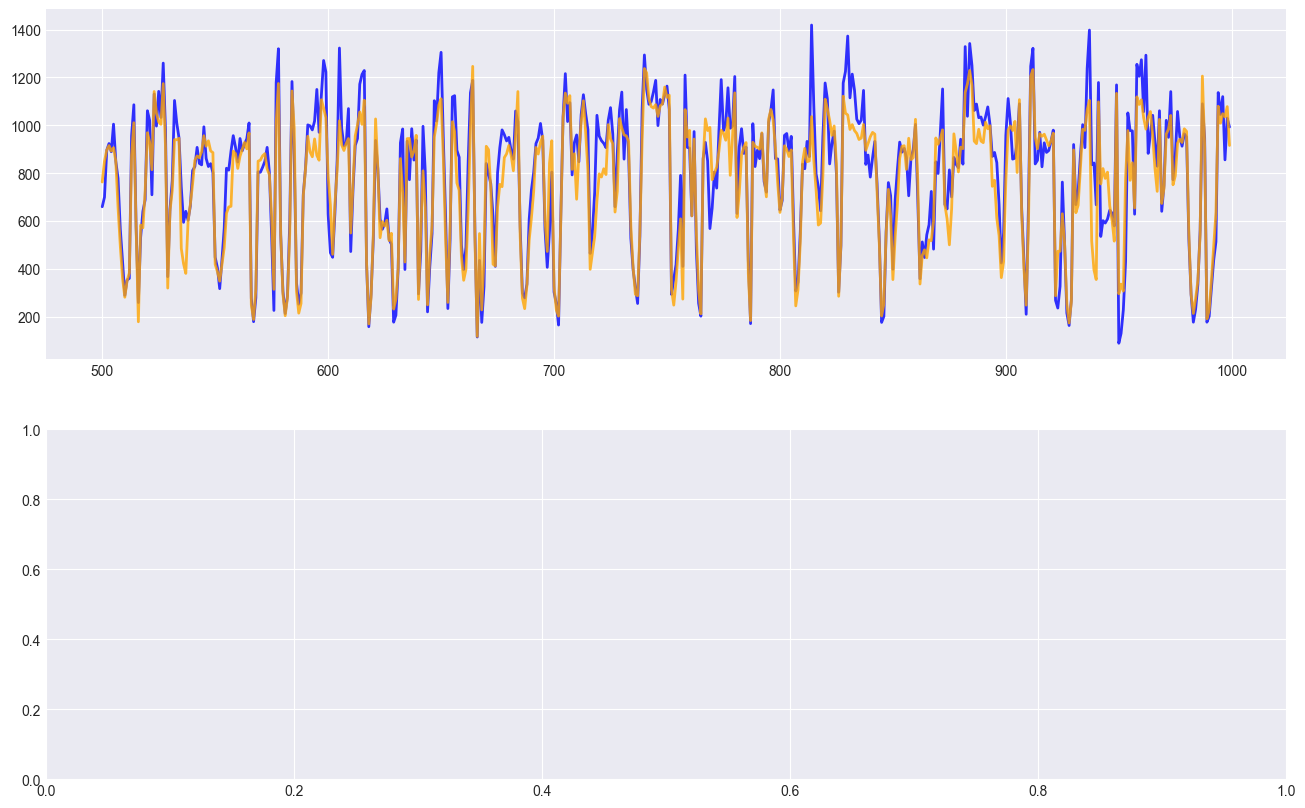

In [55]:
# ============================================================================
# 📊 VISUALISATION SIMPLE : PRÉDICTIONS VS RÉALITÉ
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

print("📊 Génération de la courbe Prédictions vs Réalité...")

# Créer la figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ============================================================================
# GRAPHIQUE 1 : Vue d'ensemble (500 premières heures)
# ============================================================================

sample_size = min(500, len(y_test))
x = range(500,500+sample_size)

axes[0].plot(x, y_test.iloc[500:500+sample_size].values, 
            label='Valeurs réelles', 
            color='blue', 
            linewidth=2, 
            alpha=0.8)

axes[0].plot(x, y_pred_xgb[500:500+sample_size], 
            label='Prédictions (Ensemble)', 
            color='orange', 
            linewidth=2, 
            alpha=0.8)

axes[0].fill_between(x, 
                     y_test.iloc[500:500+sample_size].values, 
                     y_pred_ensemble[:sample_size], 
                     alpha=0.2, 
                     color='gray',
                     label='Écart')

axes[0].set_xlabel('Index temporel (heures)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Débit horaire (véh/h)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Prédictions vs Réalité - Vue d\'ensemble ({sample_size} heures)\nRMSE: {rmse_ensemble:.2f} véh/h | MAE: {mae_ensemble:.2f} véh/h | R²: {r2_ensemble:.4f}', 
                 fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# ============================================================================
# GRAPHIQUE 2 : Zoom sur une semaine (168 heures)
# ============================================================================

week_size = min(168, len(y_test))  # 7 jours × 24 heures
x_week = range(week_size)

axes[1].plot(x_week, y_test.iloc[500:500+week_size].values, 
            label='Valeurs réelles', 
            color='blue', 
            linewidth=2.5, 
            marker='o', 
            markersize=4,
            alpha=0.8)

axes[1].plot(x_week, y_pred_xgb[500:500+week_size], 
            label='Prédictions (Ensemble)', 
            color='orange', 
            linewidth=2.5, 
            marker='s', 
            markersize=4,
            alpha=0.8)

# Lignes verticales pour séparer les jours
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
for i in range(1, min(7, week_size // 24)):
    axes[1].axvline(x=i*24, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    if i*24 < week_size:
        axes[1].text(i*24 - 12, axes[1].get_ylim()[1] * 0.95, 
                    jours[i-1] if i-1 < len(jours) else '', 
                    horizontalalignment='center',
                    fontsize=10,
                    fontweight='bold')

axes[1].set_xlabel('Heures (sur une semaine)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Débit horaire (véh/h)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Zoom détaillé : Une semaine complète ({week_size} heures)', 
                 fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(range(0, week_size, 12))

plt.tight_layout()
plt.show()

# ============================================================================
# STATISTIQUES RAPIDES
# ============================================================================

# print("\n" + "=" * 80)
# print("📈 STATISTIQUES DE PRÉDICTION")
# print("=" * 80)
# print(f"""
# Erreurs:
#   • MAE:   {mae_ensemble:.2f} véh/h
#   • RMSE:  {rmse_ensemble:.2f} véh/h  
#   • R²:    {r2_ensemble:.4f}

# Qualité:
#   • Erreur relative: {(rmse_ensemble/y_test.mean())*100:.1f}%
#   • 50% des erreurs < {np.median(np.abs(y_test.values - y_pred_ensemble)):.1f} véh/h
#   • 90% des erreurs < {np.percentile(np.abs(y_test.values - y_pred_ensemble), 90):.1f} véh/h
# """)
# print("=" * 80)